In [1]:
from IPython import get_ipython
get_ipython().run_line_magic('reset', '-sf')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
#%matplotlib notebook
# Turn off interactive mode
plt.ioff()
plt.rcParams['interactive'] = False

#sns.set()
sns.set_style("ticks")
#sns.set_style({"xtick.direction": "in","ytick.direction": "in"})
#sns.set(rc={"xtick.bottom" : True, "ytick.left" : True})

#plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=30)  # fontsize of the axes title
plt.rc('axes', labelsize=30)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=30)  # fontsize of the tick labels
plt.rc('ytick', labelsize=30)  # fontsize of the tick labels
plt.rc('legend', fontsize=30)  # legend fontsize
#plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('font', **{'family': 'serif', 'serif': ['Times New Roman']})
plt.rc('text', usetex=True)

plt.rc('xtick', direction='in') #xticks are plotted inside the figure
plt.rc('ytick', direction='in') #yticks are plotted inside the figure
plt.rcParams['xtick.major.pad'] = 10 #distance between ticks and numbers
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

# set tick width and border width
plt.rcParams['xtick.major.size'] = 7
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1

plt.rcParams['ytick.major.size'] = 7
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1

plt.rcParams['axes.linewidth'] = 2



# Large Maze

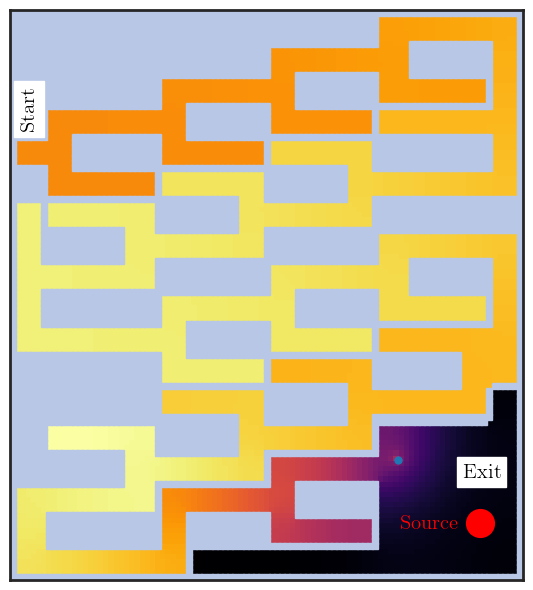

In [ ]:
# Trial plot to check the appearance

%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys
import os
import numpy as np

sys.path.append(os.path.join(os.getcwd(), 'trajectory_video'))
from maze_functions import maze_from_file, load_c_from_file, load_traj_from_file


# Data directory
data = 'trajectory_video/data_good_traj/'

# Load the maze
maze = maze_from_file('trajectory_video/different_mazes/Ran_maze_size_prop_to_droplet.tsv')
wall = np.transpose(np.where(maze == 0))

# Define the timestamp
timestamp = 73127

# Load the concentration data
conc_from_file = load_c_from_file(maze, data +'conc_' + str(timestamp) +'.txt')

# Load the particle trajectory
dx = 1
traj_from_file = np.loadtxt(data +'part_' + str(timestamp) + '.txt', skiprows=3)

# Plot concentration map
fig, ax = plt.subplots(figsize=(8, 6))
conc = ax.imshow(conc_from_file.T/np.max(conc_from_file), interpolation=None, origin='lower', cmap=plt.cm.inferno, alpha=1.0)

# Plot wall points
ax.plot(wall[:, 0], wall[:, 1], 's', markersize=4, color='#B8C7E5')

# Plot particle trajectories
x_traj = traj_from_file[1] / dx
y_traj = traj_from_file[2] / dx
time = traj_from_file[0]
ax.plot(x_traj, y_traj,'.', markersize=10.0)

# Plot source (90.2, 10.5)
source = np.array([90.2, 10.5])
ax.plot(source[0], source[1], 'o', markersize=20.0, color='red')

# Add source text
ax.text(source[0] - 4, source[1] - 2, 'Source', color='red', fontsize=15, ha='right', va='bottom')

# Add exit text
ax.text(source[0] + 4, source[1] + 8, 'Exit', color='k', fontsize=15, ha='right', va='bottom', backgroundcolor='white')

# Add start text
start = np.array([5, 86])
ax.text(start[0], start[1], 'Start', color='k', fontsize=15, ha='right', va='bottom', backgroundcolor='white', rotation='vertical')

# Set axis limits
plt.xticks([])
plt.yticks([])
fig.tight_layout()
plt.show()



In [ ]:
# Animation for Large maze

%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sys
import os
import re
import numpy as np
from tqdm.notebook import tqdm
from matplotlib.colors import Normalize
import glob

sys.path.append(os.path.join(os.getcwd(), 'trajectory_video'))
from maze_functions import maze_from_file, load_c_from_file, load_traj_from_file

# Data directory
data = 'trajectory_video/data_good_traj/'

# Load the maze
maze = maze_from_file('trajectory_video/different_mazes/Ran_maze_size_prop_to_droplet.tsv')
wall = np.transpose(np.where(maze == 0))

# Get all available timestamps
#traj_files = sorted(glob.glob(data + 'part_*.txt'))
#timestamps = sorted([int(f.split('_')[1].split('.')[0]) for f in traj_files])

# Get all available timestamps by listing files
traj_files = sorted(glob.glob(data + 'part_*.txt'))

# Extract the numerical timestamp using regex
timestamps = sorted([int(re.search(r'part_(\d+)\.txt$', f).group(1)) for f in traj_files])

# Load dt from parameter file
def get_dt_from_params(filename):
    with open(filename, 'r') as file:
        for line in file:
            parts = line.strip().split(':')
            if len(parts) == 2 and parts[0].strip() == 'dt':
                return float(parts[1].strip())
    return None

t_unit = 60/60 # min
r_unit = 1e-04 # cm
dt = get_dt_from_params(data + 'param.txt')
times = np.array(timestamps) * dt * t_unit

# Precompute formatted time strings
formatted_times = [f'Time: {t:.2f}min' for t in times]

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# **Pre-load all concentration data to avoid disk I/O in `update()`**
print("Loading all concentration data...")
concentration_data = []
vmin, vmax = float('inf'), float('-inf')

for ts in tqdm(timestamps):
    conc_data = load_c_from_file(maze, data + f'conc_{ts}.txt')
    concentration_data.append(conc_data)
    if np.any(conc_data):  # Consider only non-zero values
        vmax = max(vmax, np.max(conc_data))
        min_nonzero = np.min(conc_data[conc_data > 0])
        vmin = min(vmin, min_nonzero)

vmin = 0.0 if vmin == float('inf') else vmin
vmax = 1.0 if vmax == float('-inf') else vmax
norm = Normalize(vmin=vmin, vmax=vmax)

# Initialize the plot
conc_plot = ax.imshow(concentration_data[0].T, interpolation='None',
                      origin='lower', cmap=plt.cm.inferno, alpha=1.0, norm=norm)

# Plot wall points (static)
ax.plot(wall[:, 0], wall[:, 1], 's', markersize=6, color='#B8C7E5')

###################################################################################################################################
# Plot source (ONLY IF CHEMOATTRACTIVE)
#source = np.array([90.2, 10.5])
#ax.plot(source[0], source[1], 'o', markersize=20.0, color='red')

# Add source text
ax.text(source[0] - 4, source[1] - 2, 'No source', color='red', fontsize=15, ha='right', va='bottom')

# Add exit text
ax.text(source[0] + 4, source[1] + 8, 'Exit', color='k', fontsize=15, ha='right', va='bottom', backgroundcolor='white')

# Add start text
start = np.array([5, 86])
ax.text(start[0], start[1], 'Start', color='k', fontsize=15, ha='right', va='bottom', backgroundcolor='white', rotation='vertical')
###################################################################################################################################

# Initialize empty line for the trajectory
trajectory_line, = ax.plot([], [], 'w-', linewidth=3.0, alpha=1.0)  # Past trajectory
current_point, = ax.plot([], [], 'o', color='cyan', markersize=7)    # Current position

# Add timestamp text
timestamp_text = ax.text(0.02, 0.98, '', transform=ax.transAxes,
                         color='white', fontsize=20, verticalalignment='top')

# Remove ticks
plt.xticks([])
plt.yticks([])
fig.tight_layout()

# **Pre-load all trajectory data**
print("Loading and preprocessing all trajectory data...")
all_x_points, all_y_points = [], []
trajectory_indices = {}

current_index = 0
for ts in tqdm(timestamps):
    traj_data = np.loadtxt(data + f'part_{ts}.txt', skiprows=3)
    x_traj = np.atleast_1d(traj_data[1])  # Ensure it's always an array
    y_traj = np.atleast_1d(traj_data[2])
    
    all_x_points.extend(x_traj)
    all_y_points.extend(y_traj)
    
    current_index += len(x_traj)
    trajectory_indices[ts] = current_index

# Convert to numpy arrays for efficiency
all_x_points = np.array(all_x_points, dtype=np.float32)
all_y_points = np.array(all_y_points, dtype=np.float32)

# **Optimized update function**
def update(frame):
    timestamp = timestamps[frame]

    # Update concentration data
    conc_plot.set_array(concentration_data[frame].T)

    # Get trajectory data up to this timestamp
    end_idx = trajectory_indices[timestamp]
    trajectory_line.set_data(all_x_points[:end_idx], all_y_points[:end_idx])

    # Update current position
    if end_idx > 0:
        current_point.set_data([all_x_points[end_idx-1]], [all_y_points[end_idx-1]])

    # Use precomputed text (avoids per-frame computation)
    timestamp_text.set_text(formatted_times[frame])

    return conc_plot, trajectory_line, current_point, #timestamp_text

# Create animation
ani = animation.FuncAnimation(fig, update, frames=len(timestamps),
                              interval=100, blit=True)

# Set up the writer
Writer = animation.writers['ffmpeg']
writer = Writer(fps=40, bitrate=2000, codec='libx264', extra_args=['-crf', '17', '-threads', '16', '-preset', 'ultrafast', '-tune', 'film'])

# Save animation using ffmpeg
print("Saving animation...")
#ani.save(data + 'particle_trajectory.mp4', writer='ffmpeg', fps=40, bitrate=1800)
ani.save(data + 'particle_trajectory.mp4', writer=writer)
print("Animation saved successfully.")


Loading all concentration data...


  0%|          | 0/733 [00:00<?, ?it/s]

Loading and preprocessing all trajectory data...


  0%|          | 0/733 [00:00<?, ?it/s]

Saving animation...
Animation saved successfully.


# Small Maze

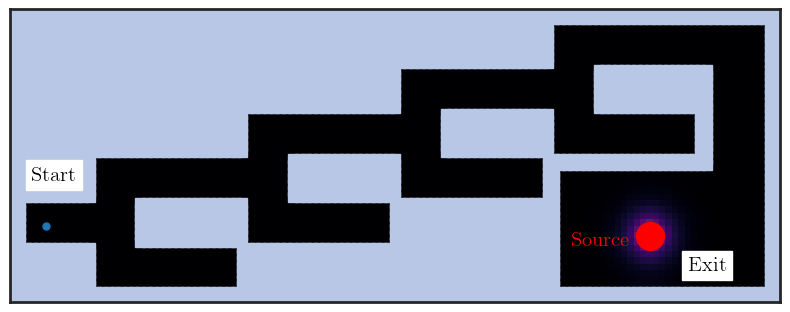

In [107]:
# Trial plot to check the appearance

%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys
import os
import numpy as np

sys.path.append(os.path.join(os.getcwd(), 'small_maze_Y'))
from maze_functions import maze_from_file, load_c_from_file, load_traj_from_file

# Data directory
data = 'small_maze_Y/data_good_CA_small_maze/'

# Load the maze
maze = maze_from_file('small_maze_Y/different_mazes/QJ01.tsv')
wall = np.transpose(np.where(maze == 0))

# Define the timestamp
timestamp = 100

# Load the concentration data
conc_from_file = load_c_from_file(maze, data +'conc_' + str(timestamp) +'.txt')

# Load the particle trajectory
dx = 1
traj_from_file = np.loadtxt(data +'part_' + str(timestamp) + '.txt', skiprows=3)

# Plot concentration map
fig, ax = plt.subplots(figsize=(8, 6))
conc = ax.imshow(conc_from_file.T/np.max(conc_from_file), interpolation=None, origin='lower', cmap=plt.cm.inferno, alpha=1.0)

# Plot wall points
ax.plot(wall[:, 0], wall[:, 1], 's', markersize=7, color='#B8C7E5')

# Plot particle trajectories
x_traj = traj_from_file[1] / dx
y_traj = traj_from_file[2] / dx
time = traj_from_file[0]
ax.plot(x_traj, y_traj,'.', markersize=10.0)

# Plot source
source = np.array([100, 9.8])
ax.plot(source[0], source[1], 'o', markersize=20.0, color='red')

# Add source text
ax.text(source[0] - 3, source[1] - 2, 'Source', color='red', fontsize=15, ha='right', va='bottom')

# Add exit text
ax.text(source[0] + 12, source[1] - 6, 'Exit', color='k', fontsize=15, ha='right', va='bottom', backgroundcolor='white')

# Add start text
start = np.array([10, 18])
ax.text(start[0], start[1], 'Start', color='k', fontsize=15, ha='right', va='bottom', backgroundcolor='white')

# Set axis limits
plt.xticks([])
plt.yticks([])
fig.tight_layout()
plt.show()



In [ ]:
# Animation for SMALL maze

%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sys
import os
import re
import numpy as np
from tqdm.notebook import tqdm
from matplotlib.colors import Normalize
import glob

sys.path.append(os.path.join(os.getcwd(), 'small_maze_Y'))
from maze_functions import maze_from_file, load_c_from_file, load_traj_from_file

# Data directory
data = 'small_maze_Y/data_good_CA_small_maze/'

# Load the maze
maze = maze_from_file('small_maze_Y/different_mazes/QJ01.tsv')
wall = np.transpose(np.where(maze == 0))

# Get all available timestamps
#traj_files = sorted(glob.glob(data + 'part_*.txt'))
#timestamps = sorted([int(f.split('_')[1].split('.')[0]) for f in traj_files])

# Get all available timestamps by listing files
traj_files = sorted(glob.glob(data + 'part_*.txt'))

# Extract the numerical timestamp using regex
timestamps = sorted([int(re.search(r'part_(\d+)\.txt$', f).group(1)) for f in traj_files])

# Load dt from parameter file
def get_dt_from_params(filename):
    with open(filename, 'r') as file:
        for line in file:
            parts = line.strip().split(':')
            if len(parts) == 2 and parts[0].strip() == 'dt':
                return float(parts[1].strip())
    return None

t_unit = 60/60 # min
r_unit = 1e-04 # cm
dt = get_dt_from_params(data + 'param.txt')
times = np.array(timestamps) * dt * t_unit

# Precompute formatted time strings
formatted_times = [f'Time: {t:.2f}min' for t in times]

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# **Pre-load all concentration data to avoid disk I/O in `update()`**
print("Loading all concentration data...")
concentration_data = []
vmin, vmax = float('inf'), float('-inf')

for ts in tqdm(timestamps):
    conc_data = load_c_from_file(maze, data + f'conc_{ts}.txt')
    concentration_data.append(conc_data)
    if np.any(conc_data):  # Consider only non-zero values
        vmax = max(vmax, np.max(conc_data))
        min_nonzero = np.min(conc_data[conc_data > 0])
        vmin = min(vmin, min_nonzero)

vmin = 0.0 if vmin == float('inf') else vmin
vmax = 1.0 if vmax == float('-inf') else vmax
norm = Normalize(vmin=vmin, vmax=vmax)

# Initialize the plot
conc_plot = ax.imshow(concentration_data[0].T, interpolation='None',
                      origin='lower', cmap=plt.cm.inferno, alpha=1.0, norm=norm)

# Plot wall points (static)
ax.plot(wall[:, 0], wall[:, 1], 's', markersize=7, color='#B8C7E5')

###################################################################################################################################
# Plot source (ONLY IF CHEMOATTRACTIVE)
source = np.array([100, 9.8])
ax.plot(source[0], source[1], 'o', markersize=20.0, color='red')

# Add source text
ax.text(source[0] - 3, source[1] - 2, 'Source', color='red', fontsize=15, ha='right', va='bottom')

# Add exit text
ax.text(source[0] + 12, source[1] - 6, 'Exit', color='k', fontsize=15, ha='right', va='bottom', backgroundcolor='white')

# Add start text
start = np.array([10, 18])
ax.text(start[0], start[1], 'Start', color='k', fontsize=15, ha='right', va='bottom', backgroundcolor='white')
###################################################################################################################################

# Initialize empty line for the trajectory
trajectory_line, = ax.plot([], [], 'w-', linewidth=3.0, alpha=1.0)  # Past trajectory
current_point, = ax.plot([], [], 'o', color='cyan', markersize=7)    # Current position

# Add timestamp text
timestamp_text = ax.text(0.02, 0.98, '', transform=ax.transAxes,
                         color='white', fontsize=20, verticalalignment='top')

# Remove ticks
plt.xticks([])
plt.yticks([])
fig.tight_layout()

# **Pre-load all trajectory data**
print("Loading and preprocessing all trajectory data...")
all_x_points, all_y_points = [], []
trajectory_indices = {}

current_index = 0
for ts in tqdm(timestamps):
    traj_data = np.loadtxt(data + f'part_{ts}.txt', skiprows=3)
    x_traj = np.atleast_1d(traj_data[1])  # Ensure it's always an array
    y_traj = np.atleast_1d(traj_data[2])
    
    all_x_points.extend(x_traj)
    all_y_points.extend(y_traj)
    
    current_index += len(x_traj)
    trajectory_indices[ts] = current_index

# Convert to numpy arrays for efficiency
all_x_points = np.array(all_x_points, dtype=np.float32)
all_y_points = np.array(all_y_points, dtype=np.float32)

# **Optimized update function**
def update(frame):
    timestamp = timestamps[frame]

    # Update concentration data
    conc_plot.set_array(concentration_data[frame].T)

    # Get trajectory data up to this timestamp
    end_idx = trajectory_indices[timestamp]
    trajectory_line.set_data(all_x_points[:end_idx], all_y_points[:end_idx])

    # Update current position
    if end_idx > 0:
        current_point.set_data([all_x_points[end_idx-1]], [all_y_points[end_idx-1]])

    # Use precomputed text (avoids per-frame computation)
    timestamp_text.set_text(formatted_times[frame])

    return conc_plot, trajectory_line, current_point, #timestamp_text

# Create animation
ani = animation.FuncAnimation(fig, update, frames=len(timestamps),
                              interval=100, blit=True)

# Set up the writer
Writer = animation.writers['ffmpeg']
writer = Writer(fps=40, bitrate=2000, codec='libx264', extra_args=['-crf', '17', '-threads', '16', '-preset', 'ultrafast', '-tune', 'film'])

# Save animation using ffmpeg
print("Saving animation...")
#ani.save(data + 'particle_trajectory.mp4', writer='ffmpeg', fps=40, bitrate=1800)
ani.save(data + 'particle_trajectory.mp4', writer=writer)
print("Animation saved successfully.")


Loading all concentration data...


  0%|          | 0/381 [00:00<?, ?it/s]

Loading and preprocessing all trajectory data...


  0%|          | 0/381 [00:00<?, ?it/s]

Saving animation...
Animation saved successfully.
